<a href="https://colab.research.google.com/github/rally-adty/UNSIA-Data-Sciense-SM-4/blob/main/Pertemuan11_M_Rally_Adityo_240401010212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 11

**Nama Lengkap :** Maulana Rally Adityo

**NIM :** (240401010212)  

**Kelas :** (IF401)

Program Studi Informatika

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

Import Library

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Load Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


Melihat informasi datasheet

In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Statistik Datasheet

In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(df)

Normalisasi Data

In [6]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

Menentukan Jumlah Cluster (Elbow Method)

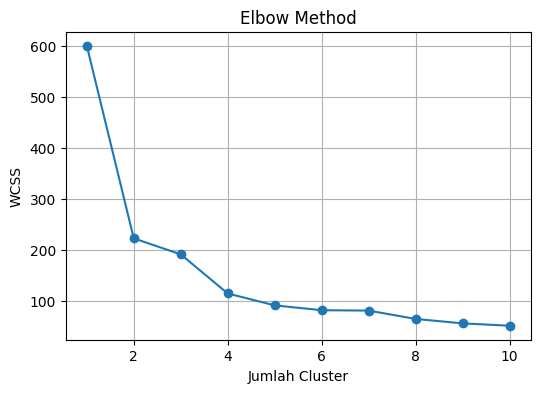

In [7]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.grid()

plt.show()

Menampilkan grafik elbow

In [10]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

cluster = kmeans.fit_predict(X)

Membuat model K-Means

In [11]:
df["Cluster"] = cluster

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


Menambahkan hasil cluster

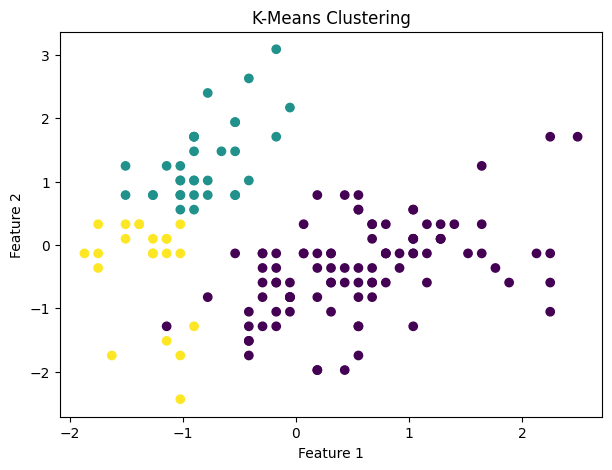

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=cluster,
    cmap="viridis"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

Visualisasi hasil K-means

In [13]:
print(kmeans.cluster_centers_)

[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


Menampilkan titik centroid

In [14]:
hc = AgglomerativeClustering(
    n_clusters=3
)

hc_cluster = hc.fit_predict(X)

Hierarchical Clustering

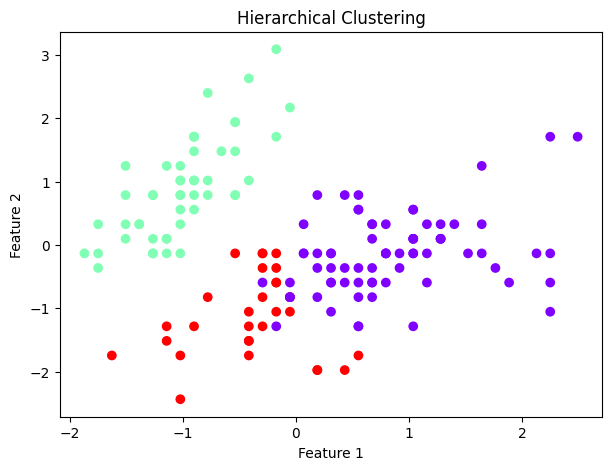

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=hc_cluster,
    cmap="rainbow"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Hierarchical Clustering")

plt.show()

Visuakisasi Hierarchical

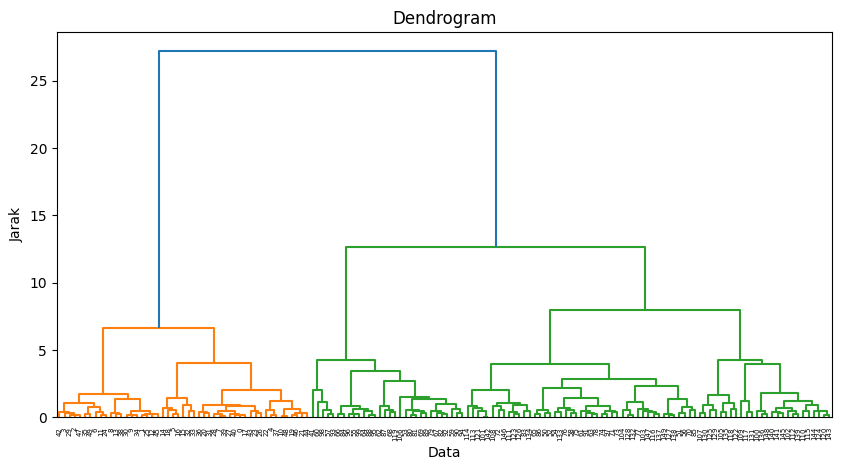

In [16]:
linked = linkage(
    X,
    method="ward"
)

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Data")
plt.ylabel("Jarak")

plt.show()

Membuat Dendogram

In [17]:
df["Cluster"].value_counts()

,count
Cluster,
0,96
1,33
2,21


Melihat jumlah anggota cluster

In [18]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,1
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,2
9,4.9,3.1,1.5,0.1,2


Menampilkan dataset akhir

Kesimpulan

Berdasarkan hasil clustering menggunakan algoritma K-Means, data berhasil dikelompokkan menjadi 3 cluster berdasarkan kemiripan karakteristik. Jumlah cluster ditentukan menggunakan Metode Elbow dengan melihat nilai WCSS. Selain itu dilakukan Hierarchical Clustering dan divisualisasikan menggunakan Dendrogram untuk melihat hubungan antar data. Hasil ini menunjukkan bahwa metode clustering mampu mengelompokkan data tanpa menggunakan label sesuai konsep Unsupervised Learning.